# Causal Analysis With Configurable Treatment (No question_id)

This notebook keeps the same causal-analysis pipeline as the no-question_id version, but makes treatment configurable:

- Default: **continuous** treatment on `temperature`.
- Optional: **binary** treatment for `temperature`, `judge_type` (one-vs-rest), `prompt_variant` (one-vs-rest), or `model` (one-vs-rest).
- `question_id` remains excluded from adjustment and moderation.

How to switch treatment:

1. Open **Cell 2** and edit `TREATMENT_CONFIG`.
2. Run **Cell 2**, then **Cell 3 onward**.

In [1]:
from __future__ import annotations

from pathlib import Path
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from graphviz import Digraph
from IPython.display import Markdown, display
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.model_selection import KFold

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
np.random.seed(42)

DATA_DIR = Path("output/result_without_rep_id")
FIG_DIR = Path("output/causal_analysis_continuous_treatment")
FIG_DIR.mkdir(parents=True, exist_ok=True)

METRIC_COLUMNS = ["Agreement (µ)", "Consistency (µ)", "Error Rate (µ)"]
COVARIATE_COLUMNS = ["judge_type", "prompt_variant", "model"]
MODERATOR_COLUMNS = ["judge_type", "prompt_variant", "model"]

# --------------------------
# Treatment configuration
# --------------------------
TREATMENT_CONFIG = {
    "variable": "temperature",   # temperature | judge_type | prompt_variant | model
    "mode": "continuous",        # continuous | binary
    "positive_level": None,      # for categorical binary treatment (one-vs-rest)
    "threshold": 1.5,            # for numeric binary treatment
    "threshold_rule": "ge",      # ge | le
}

data_paths = {
    path.stem.replace("metrics_by_question_judge_prompt_temp_", ""): path
    for path in sorted(DATA_DIR.glob("metrics_by_question_judge_prompt_temp_*.jsonl"))
}
MODEL_NAMES = list(data_paths)

if not MODEL_NAMES:
    raise FileNotFoundError(f"No model files found under {DATA_DIR}")

dfs = []
for model_name, path in data_paths.items():
    if "Thinking" in model_name:
        continue
    df = pd.read_json(path, lines=True)
    df["model"] = model_name
    dfs.append(df)

combined_df_raw = pd.concat(dfs, ignore_index=True)
combined_df_raw["temperature"] = pd.to_numeric(combined_df_raw["temperature"], errors="coerce")
combined_df_raw[METRIC_COLUMNS] = combined_df_raw[METRIC_COLUMNS].apply(pd.to_numeric, errors="coerce")
combined_df_raw["question_id"] = combined_df_raw["question_id"].astype(str)
for col in COVARIATE_COLUMNS:
    combined_df_raw[col] = combined_df_raw[col].astype("category")

AVAILABLE_LEVELS = {
    col: sorted(combined_df_raw[col].astype(str).dropna().unique().tolist())
    for col in COVARIATE_COLUMNS
}


def _unique_keep_order(cols: list[str]) -> list[str]:
    seen = set()
    out = []
    for c in cols:
        if c not in seen:
            out.append(c)
            seen.add(c)
    return out


def _ensure_feature_df(df: pd.DataFrame) -> pd.DataFrame:
    if df.shape[1] == 0:
        return pd.DataFrame({"__intercept__": np.zeros(len(df), dtype=float)}, index=df.index)
    return df


def _one_hot(df: pd.DataFrame) -> pd.DataFrame:
    return _ensure_feature_df(pd.get_dummies(df, drop_first=False, dtype=float))


def apply_treatment_config(df: pd.DataFrame, config: dict) -> tuple[pd.DataFrame, dict]:
    work = df.copy()
    variable = str(config.get("variable", "temperature"))
    mode = str(config.get("mode", "continuous")).lower().strip()

    if variable not in work.columns:
        raise ValueError(f"Unknown treatment variable: {variable}")

    treatment_col = "__treatment__"
    source_numeric = pd.to_numeric(work[variable], errors="coerce")
    numeric_ratio = float(source_numeric.notna().mean())

    if mode == "continuous":
        if numeric_ratio < 0.95:
            raise ValueError(
                f"Continuous mode requires a numeric variable. `{variable}` appears categorical."
            )
        work[treatment_col] = source_numeric.astype(float)
        label = f"Continuous treatment on `{variable}`"
        effect_axis_label = f"Effect per +1 unit of {variable}"
        is_binary = False
        positive_level = None
        threshold = None

    elif mode == "binary":
        is_numeric_binary = numeric_ratio >= 0.95
        if is_numeric_binary:
            threshold = float(config.get("threshold", 1.5))
            rule = str(config.get("threshold_rule", "ge")).lower().strip()
            if rule not in {"ge", "le"}:
                raise ValueError("`threshold_rule` must be `ge` or `le`.")
            if rule == "ge":
                treated = source_numeric >= threshold
                positive_level = f"{variable} >= {threshold}"
                control_desc = f"{variable} < {threshold}"
            else:
                treated = source_numeric <= threshold
                positive_level = f"{variable} <= {threshold}"
                control_desc = f"{variable} > {threshold}"
            work[treatment_col] = treated.astype(int)
            label = f"Binary treatment: {positive_level} (1) vs {control_desc} (0)"
        else:
            levels = sorted(work[variable].astype(str).dropna().unique().tolist())
            if not levels:
                raise ValueError(f"No levels found for `{variable}`.")
            positive_level = config.get("positive_level")
            if positive_level is None:
                positive_level = levels[0]
            positive_level = str(positive_level)
            if positive_level not in levels:
                raise ValueError(
                    f"`positive_level={positive_level}` not in levels of `{variable}`: {levels}"
                )
            work[treatment_col] = work[variable].astype(str).eq(positive_level).astype(int)
            label = f"Binary treatment: {variable} == {positive_level} (1) vs others (0)"
            threshold = None

        effect_axis_label = "ATE: treated - control"
        is_binary = True

    else:
        raise ValueError("`mode` must be `continuous` or `binary`.")

    work[treatment_col] = pd.to_numeric(work[treatment_col], errors="coerce")
    work = work.dropna(subset=[treatment_col]).copy()

    if is_binary:
        work["treatment_bucket"] = pd.Categorical(
            np.where(work[treatment_col].eq(1), "treated (1)", "control (0)"),
            categories=["control (0)", "treated (1)"],
            ordered=True,
        )
    else:
        median_value = float(np.nanmedian(work[treatment_col].to_numpy()))
        work["treatment_bucket"] = pd.Categorical(
            np.where(work[treatment_col] >= median_value, "high (>= median)", "low (< median)"),
            categories=["low (< median)", "high (>= median)"],
            ordered=True,
        )

    return work, {
        "variable": variable,
        "mode": mode,
        "is_binary": is_binary,
        "treatment_col": treatment_col,
        "label": label,
        "effect_axis_label": effect_axis_label,
        "positive_level": positive_level,
        "threshold": threshold,
    }


def make_lgbm_regressor(random_state: int = 42) -> LGBMRegressor:
    return LGBMRegressor(
        n_estimators=250,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=random_state,
        n_jobs=-1,
        verbose=-1,
    )


def make_lgbm_classifier(random_state: int = 42) -> LGBMClassifier:
    return LGBMClassifier(
        n_estimators=250,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=random_state,
        n_jobs=-1,
        verbose=-1,
    )


def standardized_mean_difference_binary(x: pd.Series, t: pd.Series) -> float:
    x = pd.to_numeric(x, errors="coerce").fillna(0.0)
    t = pd.to_numeric(t, errors="coerce").fillna(0).astype(int)
    treated = x[t.eq(1)]
    control = x[t.eq(0)]
    if len(treated) == 0 or len(control) == 0:
        return np.nan
    m1 = float(treated.mean())
    m0 = float(control.mean())
    v1 = float(treated.var(ddof=1)) if len(treated) > 1 else 0.0
    v0 = float(control.var(ddof=1)) if len(control) > 1 else 0.0
    pooled = math.sqrt(max((v1 + v0) / 2.0, 1e-12))
    return abs(m1 - m0) / pooled if pooled > 0 else 0.0


def abs_correlation(x: pd.Series, t: pd.Series) -> float:
    x = pd.to_numeric(x, errors="coerce")
    t = pd.to_numeric(t, errors="coerce")
    valid = x.notna() & t.notna()
    if int(valid.sum()) <= 2:
        return np.nan
    x_v = x[valid]
    t_v = t[valid]
    sx = float(x_v.std(ddof=1))
    st = float(t_v.std(ddof=1))
    if sx == 0.0 or st == 0.0:
        return 0.0
    return float(abs(np.corrcoef(x_v, t_v)[0, 1]))


def _feature_family(name: str) -> str:
    for family in ADJUSTMENT_COLUMNS:
        if name == family or name.startswith(f"{family}_"):
            return family
    if name == TREATMENT_COL or name.startswith(f"{TREATMENT_COL}_"):
        return TREATMENT_SOURCE
    return "other"


def make_feature_group_map(feature_names: list[str], include_treatment: bool = True) -> dict[str, str]:
    mapping = {}
    for name in feature_names:
        if include_treatment and (name == TREATMENT_COL or name.startswith(f"{TREATMENT_COL}_")):
            mapping[name] = TREATMENT_SOURCE
            continue
        assigned = False
        for family in ADJUSTMENT_COLUMNS:
            if name == family or name.startswith(f"{family}_"):
                mapping[name] = family
                assigned = True
                break
        if not assigned:
            mapping[name] = "other"
    return mapping


def compute_balance_table(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, str]:
    dummies = _one_hot(df[ADJUSTMENT_COLUMNS]) if ADJUSTMENT_COLUMNS else _ensure_feature_df(pd.DataFrame(index=df.index))
    treat = pd.to_numeric(df[TREATMENT_COL], errors="coerce")

    metric_col = "abs_smd" if TREATMENT_IS_BINARY else "abs_corr"
    detail_rows = []
    for col in dummies.columns:
        metric_value = (
            standardized_mean_difference_binary(dummies[col], treat)
            if TREATMENT_IS_BINARY
            else abs_correlation(dummies[col], treat)
        )
        detail_rows.append(
            {
                "feature": col,
                "family": _feature_family(col),
                metric_col: metric_value,
            }
        )

    balance_detail = pd.DataFrame(detail_rows).sort_values(metric_col, ascending=False).reset_index(drop=True)
    balance_summary = (
        balance_detail.groupby("family", as_index=False)[metric_col]
        .agg(["mean", "max", "median"])
        .reset_index()
        .rename(columns={"mean": f"mean_{metric_col}", "max": f"max_{metric_col}", "median": f"median_{metric_col}"})
        .sort_values(f"max_{metric_col}", ascending=False)
        .reset_index(drop=True)
    )
    return balance_summary, balance_detail, metric_col


def build_dag() -> Digraph:
    dag = Digraph()
    dag.attr(rankdir="LR")

    for idx, covariate in enumerate(ADJUSTMENT_COLUMNS):
        dag.node(f"X{idx}", covariate, shape="box")

    dag.node("T", f"{TREATMENT_SOURCE} ({TREATMENT_MODE})", shape="ellipse", style="filled", fillcolor="lightblue")
    dag.node("A", "Agreement (µ)", shape="ellipse")
    dag.node("C", "Consistency (µ)", shape="ellipse")
    dag.node("E", "Error Rate (µ)", shape="ellipse")
    dag.node("U", "latent prompt / parsing complexity", shape="diamond", style="dashed")

    for idx, _ in enumerate(ADJUSTMENT_COLUMNS):
        dag.edge(f"X{idx}", "T")
        dag.edge(f"X{idx}", "A")
        dag.edge(f"X{idx}", "C")
        dag.edge(f"X{idx}", "E")

    dag.edge("T", "A")
    dag.edge("T", "C")
    dag.edge("T", "E")
    dag.edge("U", "A", style="dashed")
    dag.edge("U", "C", style="dashed")
    dag.edge("U", "E", style="dashed")
    return dag


def cross_fitted_aipw(
    df: pd.DataFrame,
    outcome_col: str,
    treatment_col: str | None = None,
    covariate_cols: list[str] | None = None,
    n_splits: int = 3,
    random_state: int = 42,
    n_estimators: int = 250,
    trim: float = 0.025,
    return_fold_models: bool = False,
    display_progress: bool = False,
    progress_prefix: str = "",
) -> dict:
    if treatment_col is None:
        treatment_col = TREATMENT_COL
    if covariate_cols is None:
        covariate_cols = ADJUSTMENT_COLUMNS

    keep_cols = _unique_keep_order(covariate_cols + [treatment_col, outcome_col])
    work = df[keep_cols].dropna().copy()
    work[outcome_col] = pd.to_numeric(work[outcome_col], errors="coerce")
    work[treatment_col] = pd.to_numeric(work[treatment_col], errors="coerce")
    work = work.dropna(subset=[outcome_col, treatment_col]).reset_index(drop=True)

    W = _one_hot(work[covariate_cols]) if covariate_cols else _ensure_feature_df(pd.DataFrame(index=work.index))
    T = work[treatment_col].to_numpy(dtype=float)
    Y = work[outcome_col].to_numpy(dtype=float)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    if TREATMENT_IS_BINARY:
        T_int = T.astype(int)
        if np.unique(T_int).size < 2:
            raise ValueError(f"{outcome_col}: treatment has only one level after filtering.")

        mu0_hat = np.zeros(len(work), dtype=float)
        mu1_hat = np.zeros(len(work), dtype=float)
        e_hat = np.zeros(len(work), dtype=float)
        fold_models = []

        for fold_id, (train_idx, test_idx) in enumerate(kf.split(W), start=1):
            if display_progress:
                print(f"{progress_prefix}{outcome_col}: fitting fold {fold_id}/{n_splits}")

            W_train = W.iloc[train_idx]
            W_test = W.iloc[test_idx]
            T_train = T_int[train_idx]
            Y_train = Y[train_idx]

            prop_model = make_lgbm_classifier(random_state + fold_id)
            prop_model.set_params(n_estimators=n_estimators)
            prop_model.fit(W_train, T_train)
            e_hat[test_idx] = prop_model.predict_proba(W_test)[:, 1]

            mu0_model = make_lgbm_regressor(random_state + 100 + fold_id)
            mu1_model = make_lgbm_regressor(random_state + 200 + fold_id)
            mu0_model.set_params(n_estimators=n_estimators)
            mu1_model.set_params(n_estimators=n_estimators)

            mask0 = T_train == 0
            mask1 = T_train == 1
            if int(mask0.sum()) == 0 or int(mask1.sum()) == 0:
                raise ValueError(f"{outcome_col}: one treatment arm missing inside a fold.")

            mu0_model.fit(W_train.loc[mask0], Y_train[mask0])
            mu1_model.fit(W_train.loc[mask1], Y_train[mask1])

            mu0_hat[test_idx] = mu0_model.predict(W_test)
            mu1_hat[test_idx] = mu1_model.predict(W_test)

            fold_models.append(
                {
                    "propensity_model": prop_model,
                    "mu0_model": mu0_model,
                    "mu1_model": mu1_model,
                }
            )

        e_hat = np.clip(e_hat, trim, 1.0 - trim)
        pseudo_effect = mu1_hat - mu0_hat + T_int * (Y - mu1_hat) / e_hat - (1 - T_int) * (Y - mu0_hat) / (1 - e_hat)
        ate = float(np.mean(pseudo_effect))
        se = float(np.std(pseudo_effect, ddof=1) / np.sqrt(len(pseudo_effect)))
        ci_low = ate - 1.96 * se
        ci_high = ate + 1.96 * se

        result = {
            "Outcome": outcome_col,
            "N": int(len(work)),
            "Outcome mean (treated)": float(work.loc[work[treatment_col].eq(1), outcome_col].mean()),
            "Outcome mean (control)": float(work.loc[work[treatment_col].eq(0), outcome_col].mean()),
            "ATE": ate,
            "SE": se,
            "CI Low": ci_low,
            "CI High": ci_high,
            "ATE (95% CI)": f"{ate:.4f} [{ci_low:.4f}, {ci_high:.4f}]",
            "pseudo_effect": pseudo_effect,
            "analysis_df": work,
            "e_hat": e_hat,
            "mu0_hat": mu0_hat,
            "mu1_hat": mu1_hat,
            "effect_type": "binary_ate",
        }
        if return_fold_models:
            result["fold_models"] = fold_models
        return result

    e_hat = np.zeros(len(work), dtype=float)
    m_hat = np.zeros(len(work), dtype=float)
    fold_models = []

    for fold_id, (train_idx, test_idx) in enumerate(kf.split(W), start=1):
        if display_progress:
            print(f"{progress_prefix}{outcome_col}: fitting fold {fold_id}/{n_splits}")

        W_train = W.iloc[train_idx]
        W_test = W.iloc[test_idx]
        T_train = T[train_idx]
        Y_train = Y[train_idx]

        treat_model = make_lgbm_regressor(random_state + fold_id)
        outcome_model = make_lgbm_regressor(random_state + 100 + fold_id)
        treat_model.set_params(n_estimators=n_estimators)
        outcome_model.set_params(n_estimators=n_estimators)

        treat_model.fit(W_train, T_train)
        outcome_model.fit(W_train, Y_train)

        e_hat[test_idx] = treat_model.predict(W_test)
        m_hat[test_idx] = outcome_model.predict(W_test)

        fold_models.append(
            {
                "treatment_model": treat_model,
                "outcome_model": outcome_model,
            }
        )

    t_res = T - e_hat
    y_res = Y - m_hat
    a_denom = float(np.mean(t_res**2))
    if a_denom <= 1e-10:
        raise ValueError(f"{outcome_col}: treatment residual variance too small for continuous-effect estimation.")

    theta = float(np.mean(t_res * y_res) / a_denom)
    infl = (t_res * (y_res - t_res * theta)) / a_denom
    se = float(np.std(infl, ddof=1) / np.sqrt(len(infl)))
    ci_low = theta - 1.96 * se
    ci_high = theta + 1.96 * se

    q25, q75 = np.nanquantile(T, [0.25, 0.75])
    low_mean = float(np.mean(Y[T <= q25])) if np.any(T <= q25) else np.nan
    high_mean = float(np.mean(Y[T >= q75])) if np.any(T >= q75) else np.nan

    result = {
        "Outcome": outcome_col,
        "N": int(len(work)),
        "Outcome mean (treated)": high_mean,
        "Outcome mean (control)": low_mean,
        "ATE": theta,
        "SE": se,
        "CI Low": ci_low,
        "CI High": ci_high,
        "ATE (95% CI)": f"{theta:.4f} [{ci_low:.4f}, {ci_high:.4f}]",
        "pseudo_effect": infl,
        "analysis_df": work,
        "e_hat": e_hat,
        "mu0_hat": m_hat,
        "mu1_hat": m_hat,
        "effect_type": f"continuous_per_1unit_{TREATMENT_SOURCE}",
    }
    if return_fold_models:
        result["fold_models"] = fold_models
    return result


def subgroup_ate(df: pd.DataFrame, outcome_col: str, subgroup_col: str) -> pd.DataFrame:
    rows = []
    for level, group in df.groupby(subgroup_col, observed=True):
        if len(group) < 80:
            continue
        if TREATMENT_IS_BINARY and group[TREATMENT_COL].nunique() < 2:
            continue
        try:
            res = cross_fitted_aipw(
                group,
                outcome_col=outcome_col,
                n_splits=2,
                random_state=123,
                n_estimators=150,
            )
        except Exception:
            continue
        rows.append(
            {
                "Outcome": outcome_col,
                "Moderator": subgroup_col,
                "Level": str(level),
                "N": res["N"],
                "ATE": res["ATE"],
                "CI Low": res["CI Low"],
                "CI High": res["CI High"],
                "ATE (95% CI)": res["ATE (95% CI)"],
            }
        )
    if not rows:
        return pd.DataFrame(columns=["Outcome", "Moderator", "Level", "N", "ATE", "CI Low", "CI High", "ATE (95% CI)"])
    return pd.DataFrame(rows).sort_values("ATE").reset_index(drop=True)


def fit_global_nuisance_models(
    df: pd.DataFrame,
    outcome_col: str,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, LGBMRegressor, LGBMRegressor | LGBMClassifier]:
    keep_cols = _unique_keep_order([TREATMENT_COL] + ADJUSTMENT_COLUMNS + [outcome_col])
    work = df[keep_cols].dropna().copy()
    work[outcome_col] = pd.to_numeric(work[outcome_col], errors="coerce")
    work[TREATMENT_COL] = pd.to_numeric(work[TREATMENT_COL], errors="coerce")
    work = work.dropna(subset=[outcome_col, TREATMENT_COL]).reset_index(drop=True)

    X_outcome = _one_hot(work[_unique_keep_order([TREATMENT_COL] + ADJUSTMENT_COLUMNS)])
    X_treatment = _one_hot(work[ADJUSTMENT_COLUMNS]) if ADJUSTMENT_COLUMNS else _ensure_feature_df(pd.DataFrame(index=work.index))

    outcome_model = make_lgbm_regressor(777)
    outcome_model.fit(X_outcome, work[outcome_col].to_numpy())

    if TREATMENT_IS_BINARY:
        treatment_model = make_lgbm_classifier(888)
        treatment_model.fit(X_treatment, work[TREATMENT_COL].astype(int).to_numpy())
    else:
        treatment_model = make_lgbm_regressor(888)
        treatment_model.fit(X_treatment, work[TREATMENT_COL].astype(float).to_numpy())

    return work, X_outcome, X_treatment, outcome_model, treatment_model


def grouped_shap_importance(
    model,
    data: pd.DataFrame,
    feature_groups: dict[str, str],
    max_rows: int = 3000,
    random_state: int = 42,
    title: str | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    sample = data.sample(min(len(data), max_rows), random_state=random_state).copy()
    explainer = shap.TreeExplainer(model)
    explanation = explainer(sample)
    shap_values = np.asarray(explanation.values)
    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, -1]
    abs_shap = pd.DataFrame(np.abs(shap_values), columns=sample.columns)
    grouped = (
        pd.DataFrame(
            {
                "feature": sample.columns,
                "group": [feature_groups.get(col, col) for col in sample.columns],
                "mean_abs_shap": abs_shap.mean(axis=0).values,
            }
        )
        .groupby("group", as_index=False)["mean_abs_shap"]
        .sum()
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )
    if title is not None:
        grouped["title"] = title
    return grouped, sample


def placebo_permutation_test(
    df: pd.DataFrame,
    outcome_col: str,
    n_perm: int = 10,
    random_state: int = 42,
    progress_prefix: str = "",
) -> dict:
    rng = np.random.default_rng(random_state)
    observed = cross_fitted_aipw(
        df,
        outcome_col=outcome_col,
        n_splits=2,
        random_state=random_state,
        n_estimators=120,
        display_progress=False,
    )["ATE"]

    placebo_draws = []
    for perm_idx in range(n_perm):
        if progress_prefix:
            print(f"{progress_prefix}{outcome_col}: placebo permutation {perm_idx + 1}/{n_perm}")
        perm_df = df.copy()
        perm_df[TREATMENT_COL] = rng.permutation(perm_df[TREATMENT_COL].to_numpy())
        perm_effect = cross_fitted_aipw(
            perm_df,
            outcome_col=outcome_col,
            n_splits=2,
            random_state=random_state + perm_idx + 1,
            n_estimators=120,
            display_progress=False,
        )["ATE"]
        placebo_draws.append(perm_effect)

    placebo_draws = np.asarray(placebo_draws, dtype=float)
    p_value = (np.sum(np.abs(placebo_draws) >= abs(observed)) + 1) / (len(placebo_draws) + 1)
    return {
        "Outcome": outcome_col,
        "Observed ATE": float(observed),
        "Placebo mean": float(np.mean(placebo_draws)),
        "Placebo std": float(np.std(placebo_draws, ddof=1)),
        "Permutation p-value": float(p_value),
        "placebo_draws": placebo_draws,
    }


def approximate_e_value(y: pd.Series, ate: float) -> dict:
    y_clean = pd.to_numeric(y, errors="coerce").dropna()
    sd = float(y_clean.std(ddof=1)) if len(y_clean) > 1 else np.nan
    if not np.isfinite(sd) or sd == 0:
        return {"Cohen's d": np.nan, "Approx RR": np.nan, "E-value": np.nan}
    d_value = ate / sd
    rr_approx = math.exp(0.91 * abs(d_value))
    e_value = rr_approx + math.sqrt(rr_approx * (rr_approx - 1.0)) if rr_approx > 1.0 else 1.0
    return {
        "Cohen's d": float(d_value),
        "Approx RR": float(rr_approx),
        "E-value": float(e_value),
    }


def shap_stability(
    df: pd.DataFrame,
    outcome_col: str,
    raw_feature_cols: list[str],
    include_treatment: bool = True,
    n_boot: int = 8,
    max_rows: int = 2500,
    random_state: int = 42,
    progress_prefix: str = "",
) -> pd.DataFrame:
    base = df[raw_feature_cols + [outcome_col]].dropna().copy()
    frames = []
    for boot_idx in range(n_boot):
        if progress_prefix:
            print(f"{progress_prefix}{outcome_col}: SHAP bootstrap {boot_idx + 1}/{n_boot}")
        boot = base.sample(len(base), replace=True, random_state=random_state + boot_idx)
        X_boot = _one_hot(boot[raw_feature_cols])
        groups = make_feature_group_map(list(X_boot.columns), include_treatment=include_treatment)

        model = make_lgbm_regressor(random_state + 1000 + boot_idx)
        model.set_params(n_estimators=150)
        model.fit(X_boot, boot[outcome_col])

        grouped, _ = grouped_shap_importance(
            model,
            X_boot,
            feature_groups=groups,
            max_rows=max_rows,
            random_state=random_state + 2000 + boot_idx,
        )
        grouped["bootstrap"] = boot_idx
        grouped["Outcome"] = outcome_col
        frames.append(grouped)

    stability = pd.concat(frames, ignore_index=True)
    summary = (
        stability.groupby(["Outcome", "group"], as_index=False)["mean_abs_shap"]
        .agg(["mean", "std"])
        .reset_index()
        .rename(columns={"mean": "bootstrap_mean_abs_shap", "std": "bootstrap_std_abs_shap"})
        .sort_values(["Outcome", "bootstrap_mean_abs_shap"], ascending=[True, False])
        .reset_index(drop=True)
    )
    return summary


def refresh_analysis_config() -> None:
    global combined_df
    global TREATMENT_SOURCE, TREATMENT_COL, TREATMENT_MODE, TREATMENT_IS_BINARY
    global TREATMENT_LABEL, EFFECT_AXIS_LABEL
    global ADJUSTMENT_COLUMNS, MODERATOR_COLUMNS_ACTIVE, ANALYSIS_COLUMNS, COLUMN_MAP

    combined_df, treatment_meta = apply_treatment_config(combined_df_raw, TREATMENT_CONFIG)

    TREATMENT_SOURCE = treatment_meta["variable"]
    TREATMENT_COL = treatment_meta["treatment_col"]
    TREATMENT_MODE = treatment_meta["mode"]
    TREATMENT_IS_BINARY = treatment_meta["is_binary"]
    TREATMENT_LABEL = treatment_meta["label"]
    EFFECT_AXIS_LABEL = treatment_meta["effect_axis_label"]

    ADJUSTMENT_COLUMNS = [c for c in COVARIATE_COLUMNS if c != TREATMENT_SOURCE]
    MODERATOR_COLUMNS_ACTIVE = [c for c in MODERATOR_COLUMNS if c != TREATMENT_SOURCE]
    ANALYSIS_COLUMNS = _unique_keep_order([TREATMENT_SOURCE, TREATMENT_COL] + ADJUSTMENT_COLUMNS + METRIC_COLUMNS)

    treatment_role = "Binary treatment" if TREATMENT_IS_BINARY else "Continuous treatment"
    COLUMN_MAP = pd.DataFrame(
        [
            {"Role": treatment_role, "Variable": TREATMENT_SOURCE, "Description": TREATMENT_LABEL},
            {"Role": "Internal analysis column", "Variable": TREATMENT_COL, "Description": "Resolved treatment value used in models."},
            {"Role": "Outcome", "Variable": "Agreement (µ)", "Description": "Average agreement within each grouped unit."},
            {"Role": "Outcome", "Variable": "Consistency (µ)", "Description": "Average consistency within each grouped unit."},
            {"Role": "Outcome", "Variable": "Error Rate (µ)", "Description": "Average parse / format error rate within each grouped unit."},
            {"Role": "Adjustment / Moderator", "Variable": "judge_type", "Description": "Pairwise / single-answer / reference-guided judgment mode."},
            {"Role": "Adjustment / Moderator", "Variable": "prompt_variant", "Description": "Prompt strategy such as baseline or chain-of-thought."},
            {"Role": "Adjustment / Moderator", "Variable": "model", "Description": "Judge model identity."},
        ]
    )


refresh_analysis_config()

print(f"Loaded {len(combined_df_raw):,} rows from {len(MODEL_NAMES)} model files.")
print("Models:", MODEL_NAMES)
print("Available binary levels:")
for key in ["judge_type", "prompt_variant", "model"]:
    print(f" - {key}: {AVAILABLE_LEVELS[key]}")
print("Active treatment config:", TREATMENT_CONFIG)
print("Resolved treatment label:", TREATMENT_LABEL)
print("Adjustment columns:", ADJUSTMENT_COLUMNS)
print("Moderator columns:", MODERATOR_COLUMNS_ACTIVE)

Loaded 72,000 rows from 5 model files.
Models: ['Llama-3.1-8B-Instruct', 'Qwen3-30B-A3B-Instruct-2507', 'Qwen3-Next-80B-A3B-Instruct-FP8', 'Qwen3-Next-80B-A3B-Thinking-FP8', 'gemma-3-27b-it']
Available binary levels:
 - judge_type: ['pairwise', 'reference_guided', 'single_answer']
 - prompt_variant: ['baseline', 'cot']
 - model: ['Llama-3.1-8B-Instruct', 'Qwen3-30B-A3B-Instruct-2507', 'Qwen3-Next-80B-A3B-Instruct-FP8', 'gemma-3-27b-it']
Active treatment config: {'variable': 'temperature', 'mode': 'continuous', 'positive_level': None, 'threshold': 1.5, 'threshold_rule': 'ge'}
Resolved treatment label: Continuous treatment on `temperature`
Adjustment columns: ['judge_type', 'prompt_variant', 'model']
Moderator columns: ['judge_type', 'prompt_variant', 'model']


,Role,Variable,Description
0,Continuous treatment,temperature,Continuous treatment on `temperature`
1,Internal analysis column,__treatment__,Resolved treatment value used in models.
2,Outcome,Agreement (µ),Average agreement within each grouped unit.
3,Outcome,Consistency (µ),Average consistency within each grouped unit.
4,Outcome,Error Rate (µ),Average parse / format error rate within each ...
5,Adjustment / Moderator,judge_type,Pairwise / single-answer / reference-guided ju...
6,Adjustment / Moderator,prompt_variant,Prompt strategy such as baseline or chain-of-t...
7,Adjustment / Moderator,model,Judge model identity.


,temperature,__treatment__,judge_type,prompt_variant,model,Agreement (µ),Consistency (µ),Error Rate (µ)
0,0.01,0.01,pairwise,baseline,Llama-3.1-8B-Instruct,1.000000,1.000000,0.0
1,0.50,0.50,pairwise,baseline,Llama-3.1-8B-Instruct,1.000000,1.000000,0.0
2,1.00,1.00,pairwise,baseline,Llama-3.1-8B-Instruct,0.900000,0.777778,0.0
3,1.50,1.50,pairwise,baseline,Llama-3.1-8B-Instruct,0.333333,0.000000,0.1
4,2.00,2.00,pairwise,baseline,Llama-3.1-8B-Instruct,0.000000,1.000000,0.1


Agreement (µ)                   Consistency (µ)                    \
                     mean     std  min  max            mean     std  min  max   
temperature                                                                     
0.01               0.5323  0.4748  0.0  1.0          0.9262  0.1812  0.0  1.0   
0.50               0.5267  0.4539  0.0  1.0          0.8639  0.2338  0.0  1.0   
1.00               0.5232  0.4350  0.0  1.0          0.8059  0.2748  0.0  1.0   
1.50               0.4977  0.4365  0.0  1.0          0.8077  0.2630  0.0  1.0   
2.00               0.4783  0.4453  0.0  1.0          0.8333  0.2459  0.0  1.0   
3.00               0.4552  0.4170  0.0  1.0          0.7487  0.2877  0.0  1.0   

            Error Rate (µ)                    
                      mean     std  min  max  
temperature                                   
0.01                0.0492  0.1892  0.0  1.0  
0.50                0.0529  0.1735  0.0  1.0  
1.00                0.0658  0.1749  0.0  1.0  
1.50                0.1080  0.2485  0.0  1.0  
2.00                0.1382  0.2584  0.0  1.0  
3.00                0.2049  0.2715  0.0  1.0

,rows
treatment_bucket,
low (< median),36000
high (>= median),36000


Balance summary by covariate family (abs_corr):


,index,family,mean_abs_corr,max_abs_corr,median_abs_corr
0,1,model,0.0,0.0,0.0
1,0,judge_type,0.0,0.0,0.0
2,2,prompt_variant,0.0,0.0,0.0


Largest individual imbalances (abs_corr):


,feature,family,abs_corr
0,model_gemma-3-27b-it,model,0.0
1,model_Qwen3-30B-A3B-Instruct-2507,model,0.0
2,model_Qwen3-Next-80B-A3B-Instruct-FP8,model,0.0
3,model_Llama-3.1-8B-Instruct,model,0.0
4,judge_type_pairwise,judge_type,0.0
5,judge_type_single_answer,judge_type,0.0
6,judge_type_reference_guided,judge_type,0.0
7,prompt_variant_cot,prompt_variant,0.0
8,prompt_variant_baseline,prompt_variant,0.0


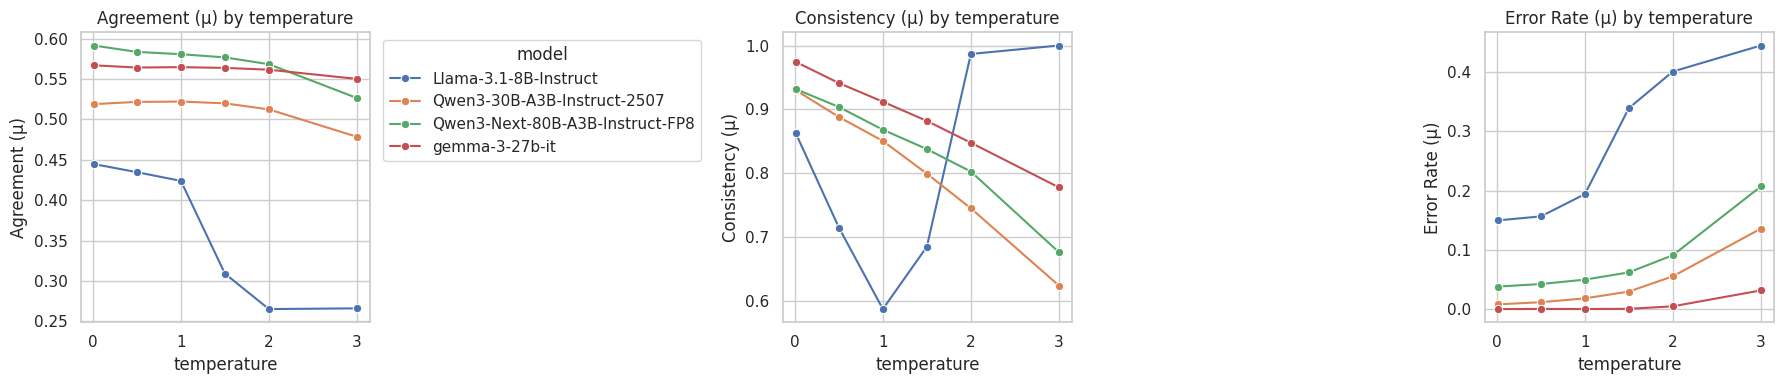

Saved: output/causal_analysis_continuous_treatment/temperature_metric_trends_by_model.png


In [2]:
# Re-resolve treatment after any edits to TREATMENT_CONFIG in Cell 2.
refresh_analysis_config()

display(COLUMN_MAP)
display(combined_df[ANALYSIS_COLUMNS].head())

descriptive_stats = (
    combined_df.groupby(TREATMENT_SOURCE, observed=True)[METRIC_COLUMNS]
    .agg(["mean", "std", "min", "max"])
    .round(4)
)
display(descriptive_stats)

treatment_counts = combined_df["treatment_bucket"].value_counts().rename_axis("treatment_bucket").to_frame("rows")
display(treatment_counts)

balance_summary, balance_detail, balance_metric_col = compute_balance_table(combined_df)
print(f"Balance summary by covariate family ({balance_metric_col}):")
display(balance_summary.round(4))

print(f"Largest individual imbalances ({balance_metric_col}):")
display(balance_detail.head(10).round(4))

if TREATMENT_SOURCE == "model":
    hue_col = "prompt_variant"
else:
    hue_col = "model"

trend_df = (
    combined_df.groupby([TREATMENT_SOURCE, hue_col], observed=True)[METRIC_COLUMNS]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=False)
for ax, outcome_col in zip(axes, METRIC_COLUMNS):
    sns.lineplot(
        data=trend_df,
        x=TREATMENT_SOURCE,
        y=outcome_col,
        hue=hue_col,
        marker="o",
        ax=ax,
    )
    ax.set_title(f"{outcome_col} by {TREATMENT_SOURCE}")
    ax.set_xlabel(TREATMENT_SOURCE)
    ax.set_ylabel(outcome_col)
    if ax is not axes[0]:
        ax.get_legend().remove()

axes[0].legend(title=hue_col, bbox_to_anchor=(1.02, 1.0), loc="upper left")
plt.tight_layout()
trend_path = FIG_DIR / f"{TREATMENT_SOURCE}_metric_trends_by_{hue_col}.png"
fig.savefig(trend_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", trend_path)

## 1. Introduction
Primary causal question: what is the causal effect of **Continuous treatment on `temperature`** on each metric?

## 3. Identification and Effect Estimation
We assume conditional unconfoundedness after adjusting for `judge_type, prompt_variant, model` (question_id excluded), and use the same variables as subgroup moderators when feasible.

Estimator: cross-fitted orthogonalized DML for continuous treatment; effect is interpreted per +1 unit of `temperature`.

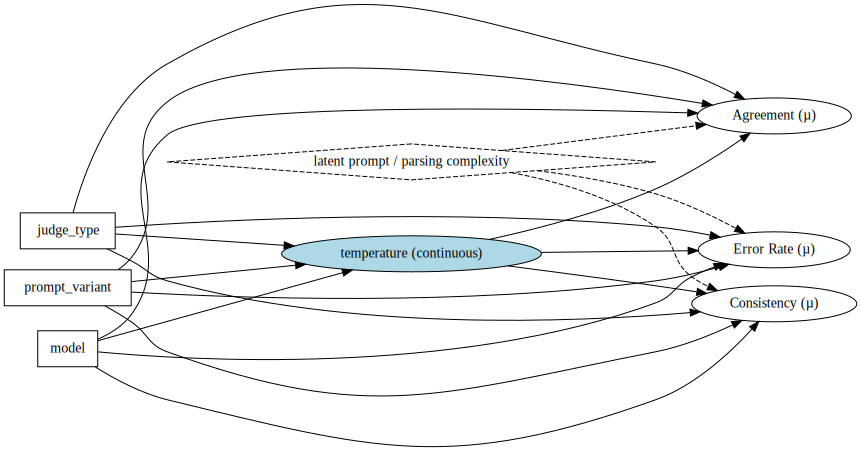

Saved: output/causal_analysis_continuous_treatment/treatment_causal_dag.png
[Effect] Agreement (µ): fitting fold 1/3
[Effect] Agreement (µ): fitting fold 2/3
[Effect] Agreement (µ): fitting fold 3/3
[Effect] Consistency (µ): fitting fold 1/3
[Effect] Consistency (µ): fitting fold 2/3
[Effect] Consistency (µ): fitting fold 3/3
[Effect] Error Rate (µ): fitting fold 1/3
[Effect] Error Rate (µ): fitting fold 2/3
[Effect] Error Rate (µ): fitting fold 3/3


,Outcome,N,Outcome mean (control),Outcome mean (treated),ATE,SE,CI Low,CI High,ATE (95% CI),Effect Type
0,Agreement (µ),71103,0.529477,0.466727,-0.027314,0.001642,-0.030532,-0.024095,"-0.0273 [-0.0305, -0.0241]",continuous_per_1unit_temperature
1,Consistency (µ),68598,0.894853,0.791215,-0.057816,0.000935,-0.059649,-0.055984,"-0.0578 [-0.0596, -0.0560]",continuous_per_1unit_temperature
2,Error Rate (µ),72000,0.051063,0.171564,0.055032,0.000669,0.053722,0.056343,"0.0550 [0.0537, 0.0563]",continuous_per_1unit_temperature


Saved: output/causal_analysis_continuous_treatment/effect_estimates.csv
Moderator summary: judge_type


,Outcome,Moderator,Level,N,ATE,CI Low,CI High,ATE (95% CI)
0,Agreement (µ),judge_type,reference_guided,23807,-0.039110,-0.044673,-0.033547,"-0.0391 [-0.0447, -0.0335]"
1,Agreement (µ),judge_type,pairwise,23896,-0.026439,-0.032242,-0.020637,"-0.0264 [-0.0322, -0.0206]"
2,Agreement (µ),judge_type,single_answer,23400,-0.016391,-0.021727,-0.011055,"-0.0164 [-0.0217, -0.0111]"
3,Consistency (µ),judge_type,single_answer,21070,-0.095969,-0.099436,-0.092502,"-0.0960 [-0.0994, -0.0925]"
4,Consistency (µ),judge_type,pairwise,23812,-0.043132,-0.045920,-0.040344,"-0.0431 [-0.0459, -0.0403]"
5,Consistency (µ),judge_type,reference_guided,23716,-0.042466,-0.045721,-0.039212,"-0.0425 [-0.0457, -0.0392]"
6,Error Rate (µ),judge_type,reference_guided,24000,0.032485,0.030338,0.034633,"0.0325 [0.0303, 0.0346]"
7,Error Rate (µ),judge_type,pairwise,24000,0.042864,0.041054,0.044675,"0.0429 [0.0411, 0.0447]"
8,Error Rate (µ),judge_type,single_answer,24000,0.089890,0.087169,0.092612,"0.0899 [0.0872, 0.0926]"


Saved: output/causal_analysis_continuous_treatment/moderator_effect_judge_type.csv
Moderator summary: prompt_variant


,Outcome,Moderator,Level,N,ATE,CI Low,CI High,ATE (95% CI)
0,Agreement (µ),prompt_variant,cot,35497,-0.036212,-0.040635,-0.031790,"-0.0362 [-0.0406, -0.0318]"
1,Agreement (µ),prompt_variant,baseline,35606,-0.018363,-0.023037,-0.013689,"-0.0184 [-0.0230, -0.0137]"
2,Consistency (µ),prompt_variant,cot,34170,-0.060027,-0.062830,-0.057225,"-0.0600 [-0.0628, -0.0572]"
3,Consistency (µ),prompt_variant,baseline,34428,-0.055667,-0.058031,-0.053302,"-0.0557 [-0.0580, -0.0533]"
4,Error Rate (µ),prompt_variant,baseline,36000,0.038977,0.037483,0.040471,"0.0390 [0.0375, 0.0405]"
5,Error Rate (µ),prompt_variant,cot,36000,0.071125,0.069005,0.073246,"0.0711 [0.0690, 0.0732]"


Saved: output/causal_analysis_continuous_treatment/moderator_effect_prompt_variant.csv
Moderator summary: model


,Outcome,Moderator,Level,N,ATE,CI Low,CI High,ATE (95% CI)
0,Agreement (µ),model,Llama-3.1-8B-Instruct,17183,-0.073268,-0.079891,-0.066645,"-0.0733 [-0.0799, -0.0666]"
1,Agreement (µ),model,Qwen3-Next-80B-A3B-Instruct-FP8,17929,-0.019858,-0.026141,-0.013575,"-0.0199 [-0.0261, -0.0136]"
2,Agreement (µ),model,Qwen3-30B-A3B-Instruct-2507,17993,-0.012933,-0.019058,-0.006809,"-0.0129 [-0.0191, -0.0068]"
3,Agreement (µ),model,gemma-3-27b-it,17998,-0.004569,-0.011229,0.002091,"-0.0046 [-0.0112, 0.0021]"
4,Consistency (µ),model,Qwen3-30B-A3B-Instruct-2507,17982,-0.102385,-0.105892,-0.098878,"-0.1024 [-0.1059, -0.0989]"
5,Consistency (µ),model,Qwen3-Next-80B-A3B-Instruct-FP8,17828,-0.083116,-0.086727,-0.079504,"-0.0831 [-0.0867, -0.0795]"
6,Consistency (µ),model,gemma-3-27b-it,17997,-0.065233,-0.068231,-0.062235,"-0.0652 [-0.0682, -0.0622]"
7,Consistency (µ),model,Llama-3.1-8B-Instruct,14791,0.053569,0.049922,0.057215,"0.0536 [0.0499, 0.0572]"
8,Error Rate (µ),model,gemma-3-27b-it,18000,0.009526,0.008764,0.010289,"0.0095 [0.0088, 0.0103]"
9,Error Rate (µ),model,Qwen3-30B-A3B-Instruct-2507,18000,0.041540,0.039615,0.043465,"0.0415 [0.0396, 0.0435]"


Saved: output/causal_analysis_continuous_treatment/moderator_effect_model.csv


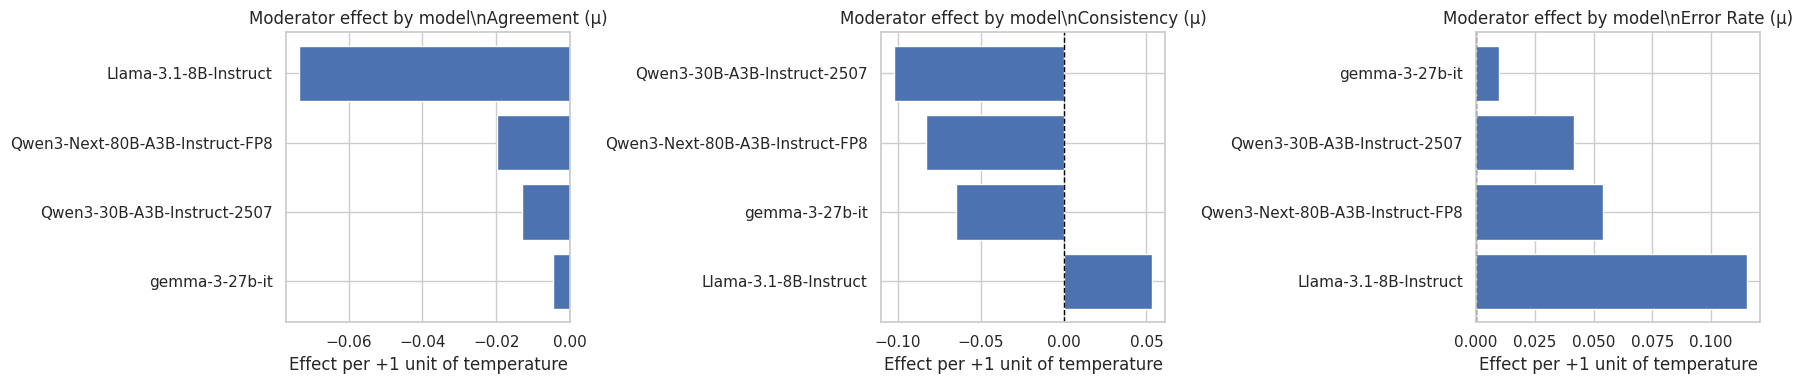

Saved: output/causal_analysis_continuous_treatment/moderator_effect_by_model.png


In [3]:
display(Markdown(f"## 1. Introduction\nPrimary causal question: what is the causal effect of **{TREATMENT_LABEL}** on each metric?"))

identification_line = (
    f"We assume conditional unconfoundedness after adjusting for `{', '.join(ADJUSTMENT_COLUMNS)}` "
    "(question_id excluded), and use the same variables as subgroup moderators when feasible."
)
if TREATMENT_IS_BINARY:
    estimator_line = "Estimator: cross-fitted AIPW for binary treatment."
else:
    estimator_line = (
        f"Estimator: cross-fitted orthogonalized DML for continuous treatment; "
        f"effect is interpreted per +1 unit of `{TREATMENT_SOURCE}`."
    )

display(Markdown(f"## 3. Identification and Effect Estimation\n{identification_line}\n\n{estimator_line}"))

dag = build_dag()
display(dag)
try:
    dag_path = FIG_DIR / "treatment_causal_dag"
    dag.render(dag_path.as_posix(), format="png", cleanup=True)
    print("Saved:", dag_path.with_suffix(".png"))
except Exception as exc:
    print("DAG render skipped:", repr(exc))

aipw_results = {}
ate_rows = []
for outcome_col in METRIC_COLUMNS:
    result = cross_fitted_aipw(
        combined_df,
        outcome_col=outcome_col,
        n_splits=3,
        random_state=42,
        n_estimators=200,
        display_progress=True,
        progress_prefix="[Effect] ",
    )
    aipw_results[outcome_col] = result
    ate_rows.append(
        {
            "Outcome": outcome_col,
            "N": result["N"],
            "Outcome mean (control)": result["Outcome mean (control)"],
            "Outcome mean (treated)": result["Outcome mean (treated)"],
            "ATE": result["ATE"],
            "SE": result["SE"],
            "CI Low": result["CI Low"],
            "CI High": result["CI High"],
            "ATE (95% CI)": result["ATE (95% CI)"],
            "Effect Type": result["effect_type"],
        }
    )

ate_table = pd.DataFrame(ate_rows)
display(ate_table)
ate_path = FIG_DIR / "effect_estimates.csv"
ate_table.to_csv(ate_path, index=False)
print("Saved:", ate_path)

moderator_results = {}
for moderator in MODERATOR_COLUMNS_ACTIVE:
    frames = []
    for outcome_col in METRIC_COLUMNS:
        subgroup_table = subgroup_ate(combined_df, outcome_col=outcome_col, subgroup_col=moderator)
        if len(subgroup_table) == 0:
            continue
        frames.append(subgroup_table)
    if not frames:
        continue
    moderator_results[moderator] = pd.concat(frames, ignore_index=True)

if moderator_results:
    for moderator, table in moderator_results.items():
        print(f"Moderator summary: {moderator}")
        display(table.head(12))
        moderator_path = FIG_DIR / f"moderator_effect_{moderator}.csv"
        table.to_csv(moderator_path, index=False)
        print("Saved:", moderator_path)

    plot_moderator = "model" if "model" in moderator_results else list(moderator_results.keys())[0]
    model_moderator_plot = moderator_results[plot_moderator].copy()

    fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=False)
    for ax, outcome_col in zip(axes, METRIC_COLUMNS):
        plot_df = model_moderator_plot.loc[model_moderator_plot["Outcome"] == outcome_col].copy()
        plot_df = plot_df.sort_values("ATE", ascending=False)
        if len(plot_df) == 0:
            ax.set_visible(False)
            continue
        ax.barh(plot_df["Level"], plot_df["ATE"], color="#4c72b0")
        ax.axvline(0.0, color="black", linestyle="--", linewidth=1)
        ax.set_title(f"Moderator effect by {plot_moderator}\\n{outcome_col}")
        ax.set_xlabel(EFFECT_AXIS_LABEL)

    plt.tight_layout()
    moderator_fig_path = FIG_DIR / f"moderator_effect_by_{plot_moderator}.png"
    fig.savefig(moderator_fig_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", moderator_fig_path)
else:
    print("No valid moderator subgroup results for current treatment configuration.")

## 4. Shapley-based Feature Attribution
True causal SHAP is not directly available in this environment, so we report grouped SHAP on nuisance models used by the doubly robust / orthogonalized pipeline.

[SHAP] fitting nuisance models for Agreement (µ)
[SHAP] fitting nuisance models for Consistency (µ)
[SHAP] fitting nuisance models for Error Rate (µ)
Outcome-model grouped SHAP:


,group,mean_abs_shap,title,Outcome
0,model,0.091106,Agreement (µ),Agreement (µ)
1,judge_type,0.032863,Agreement (µ),Agreement (µ)
2,temperature,0.025635,Agreement (µ),Agreement (µ)
3,prompt_variant,0.007957,Agreement (µ),Agreement (µ)
4,model,0.065459,Consistency (µ),Consistency (µ)
5,judge_type,0.056325,Consistency (µ),Consistency (µ)
6,temperature,0.055207,Consistency (µ),Consistency (µ)
7,prompt_variant,0.032309,Consistency (µ),Consistency (µ)
8,model,0.112797,Error Rate (µ),Error Rate (µ)
9,temperature,0.050135,Error Rate (µ),Error Rate (µ)


Treatment-model grouped SHAP:


,group,mean_abs_shap,title,Outcome
0,model,0.007508,Agreement (µ),Agreement (µ)
1,judge_type,0.003931,Agreement (µ),Agreement (µ)
2,prompt_variant,0.001440,Agreement (µ),Agreement (µ)
3,judge_type,0.063177,Consistency (µ),Consistency (µ)
4,model,0.060854,Consistency (µ),Consistency (µ)
5,prompt_variant,0.001882,Consistency (µ),Consistency (µ)
6,judge_type,0.000000,Error Rate (µ),Error Rate (µ)
7,model,0.000000,Error Rate (µ),Error Rate (µ)
8,prompt_variant,0.000000,Error Rate (µ),Error Rate (µ)


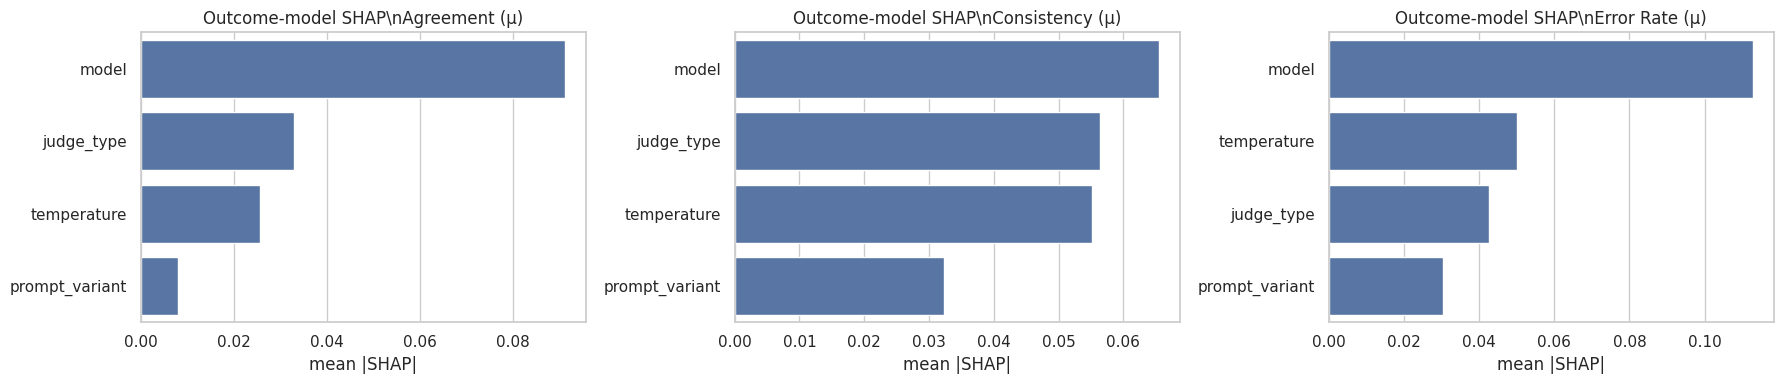

Saved: output/causal_analysis_continuous_treatment/outcome_model_grouped_shap.png


## 5. Robustness Checks

[Placebo] Agreement (µ): placebo permutation 1/10
[Placebo] Agreement (µ): placebo permutation 2/10
[Placebo] Agreement (µ): placebo permutation 3/10
[Placebo] Agreement (µ): placebo permutation 4/10
[Placebo] Agreement (µ): placebo permutation 5/10
[Placebo] Agreement (µ): placebo permutation 6/10
[Placebo] Agreement (µ): placebo permutation 7/10
[Placebo] Agreement (µ): placebo permutation 8/10
[Placebo] Agreement (µ): placebo permutation 9/10
[Placebo] Agreement (µ): placebo permutation 10/10
[Placebo] Consistency (µ): placebo permutation 1/10
[Placebo] Consistency (µ): placebo permutation 2/10
[Placebo] Consistency (µ): placebo permutation 3/10
[Placebo] Consistency (µ): placebo permutation 4/10
[Placebo] Consistency (µ): placebo permutation 5/10
[Placebo] Consistency (µ): placebo permutation 6/10
[Placebo] Consistency (µ): placebo permutation 7/10
[Placebo] Consistency (µ): placebo permutation 8/10
[Placebo] Consistency (µ): placebo permutation 9/10
[Placebo] Consistency (µ): plac

,Outcome,Observed ATE,Placebo mean,Placebo std,Permutation p-value
0,Agreement (µ),-0.027348,0.000519,0.001337,0.090909
1,Consistency (µ),-0.057760,-0.000492,0.001206,0.090909
2,Error Rate (µ),0.055052,0.000018,0.000635,0.090909


Saved: output/causal_analysis_continuous_treatment/placebo_permutation_results.csv


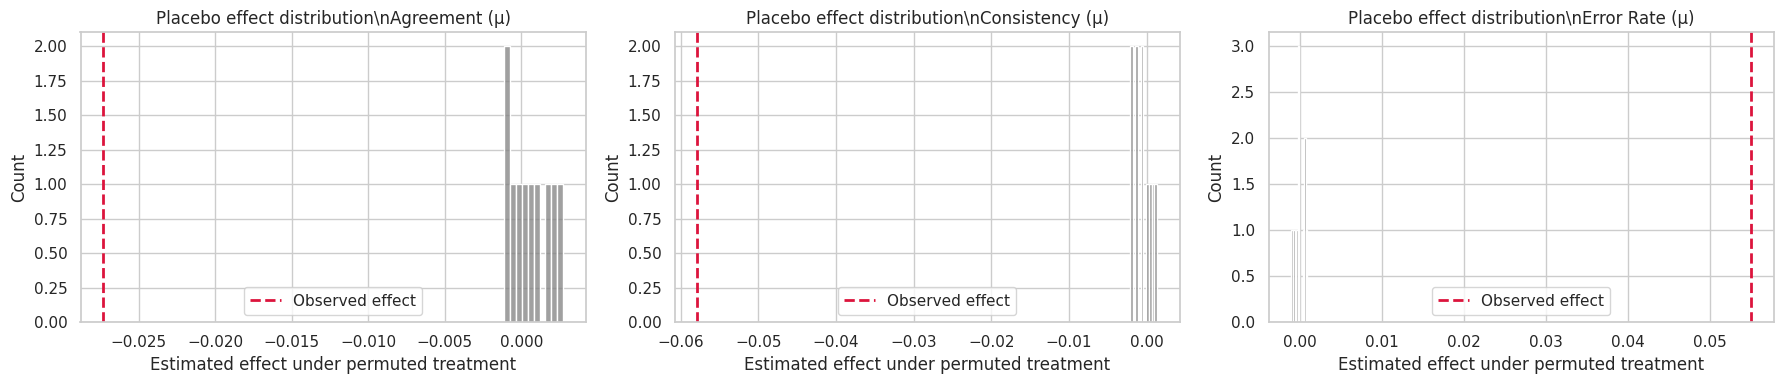

Saved: output/causal_analysis_continuous_treatment/placebo_permutation_histograms.png


,Cohen's d,Approx RR,E-value,Outcome
0,-0.061391,1.057456,1.303946,Agreement (µ)
1,-0.226130,1.228481,1.758277,Consistency (µ)
2,0.239365,1.243366,1.793450,Error Rate (µ)


Saved: output/causal_analysis_continuous_treatment/approximate_evalues.csv
[SHAP stability] Agreement (µ): SHAP bootstrap 1/8
[SHAP stability] Agreement (µ): SHAP bootstrap 2/8
[SHAP stability] Agreement (µ): SHAP bootstrap 3/8
[SHAP stability] Agreement (µ): SHAP bootstrap 4/8
[SHAP stability] Agreement (µ): SHAP bootstrap 5/8
[SHAP stability] Agreement (µ): SHAP bootstrap 6/8
[SHAP stability] Agreement (µ): SHAP bootstrap 7/8
[SHAP stability] Agreement (µ): SHAP bootstrap 8/8
[SHAP stability] Consistency (µ): SHAP bootstrap 1/8
[SHAP stability] Consistency (µ): SHAP bootstrap 2/8
[SHAP stability] Consistency (µ): SHAP bootstrap 3/8
[SHAP stability] Consistency (µ): SHAP bootstrap 4/8
[SHAP stability] Consistency (µ): SHAP bootstrap 5/8
[SHAP stability] Consistency (µ): SHAP bootstrap 6/8
[SHAP stability] Consistency (µ): SHAP bootstrap 7/8
[SHAP stability] Consistency (µ): SHAP bootstrap 8/8
[SHAP stability] Error Rate (µ): SHAP bootstrap 1/8
[SHAP stability] Error Rate (µ): SHAP boo

,index,Outcome,group,bootstrap_mean_abs_shap,bootstrap_std_abs_shap
0,1,Agreement (µ),model,0.090854,0.002333
1,0,Agreement (µ),judge_type,0.032815,0.001398
2,3,Agreement (µ),temperature,0.025714,0.000997
3,2,Agreement (µ),prompt_variant,0.008790,0.000742
4,1,Consistency (µ),model,0.066239,0.001462
5,0,Consistency (µ),judge_type,0.056126,0.000923
6,3,Consistency (µ),temperature,0.055295,0.001129
7,2,Consistency (µ),prompt_variant,0.031683,0.000504
8,1,Error Rate (µ),model,0.111673,0.002029
9,3,Error Rate (µ),temperature,0.049631,0.000944


Saved: output/causal_analysis_continuous_treatment/shap_stability_summary.csv


## 6. Discussion

,Outcome,Effect interpretation,Top SHAP driver,Strongest moderator level,Permutation p-value,Approx E-value
0,Agreement (µ),A +1 unit increase in temperature decreases Ag...,model,Llama-3.1-8B-Instruct,0.090909,1.303946
1,Consistency (µ),A +1 unit increase in temperature decreases Co...,model,Qwen3-30B-A3B-Instruct-2507,0.090909,1.758277
2,Error Rate (µ),A +1 unit increase in temperature increases Er...,model,Llama-3.1-8B-Instruct,0.090909,1.793450


Saved: output/causal_analysis_continuous_treatment/discussion_summary.csv


## Automatically generated discussion
- **Agreement (µ)**: A +1 unit increase in temperature decreases Agreement (µ) by 0.0273 on average. Top outcome-model SHAP driver: `model`. Strongest moderator level: `Llama-3.1-8B-Instruct`. Permutation p-value = 0.0909; approximate E-value = 1.3039.
- **Consistency (µ)**: A +1 unit increase in temperature decreases Consistency (µ) by 0.0578 on average. Top outcome-model SHAP driver: `model`. Strongest moderator level: `Qwen3-30B-A3B-Instruct-2507`. Permutation p-value = 0.0909; approximate E-value = 1.7583.
- **Error Rate (µ)**: A +1 unit increase in temperature increases Error Rate (µ) by 0.0550 on average. Top outcome-model SHAP driver: `model`. Strongest moderator level: `Llama-3.1-8B-Instruct`. Permutation p-value = 0.0909; approximate E-value = 1.7934.

In [4]:
display(Markdown("## 4. Shapley-based Feature Attribution\nTrue causal SHAP is not directly available in this environment, so we report grouped SHAP on nuisance models used by the doubly robust / orthogonalized pipeline."))

outcome_shap_tables = []
treatment_shap_tables = []
for outcome_col in METRIC_COLUMNS:
    print(f"[SHAP] fitting nuisance models for {outcome_col}")
    nuisance_df, X_outcome, X_treatment, outcome_model, treatment_model = fit_global_nuisance_models(combined_df, outcome_col)

    outcome_feature_groups = make_feature_group_map(list(X_outcome.columns), include_treatment=True)
    treatment_feature_groups = make_feature_group_map(list(X_treatment.columns), include_treatment=False)

    grouped_outcome_shap, _ = grouped_shap_importance(
        outcome_model,
        X_outcome,
        feature_groups=outcome_feature_groups,
        max_rows=3000,
        random_state=42,
        title=outcome_col,
    )
    grouped_outcome_shap["Outcome"] = outcome_col
    outcome_shap_tables.append(grouped_outcome_shap)

    grouped_treatment_shap, _ = grouped_shap_importance(
        treatment_model,
        X_treatment,
        feature_groups=treatment_feature_groups,
        max_rows=3000,
        random_state=84,
        title=outcome_col,
    )
    grouped_treatment_shap["Outcome"] = outcome_col
    treatment_shap_tables.append(grouped_treatment_shap)

outcome_shap_df = pd.concat(outcome_shap_tables, ignore_index=True)
treatment_shap_df = pd.concat(treatment_shap_tables, ignore_index=True)

print("Outcome-model grouped SHAP:")
display(outcome_shap_df)

print("Treatment-model grouped SHAP:")
display(treatment_shap_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=False)
for ax, outcome_col in zip(axes, METRIC_COLUMNS):
    plot_df = outcome_shap_df.loc[outcome_shap_df["Outcome"] == outcome_col].sort_values("mean_abs_shap", ascending=False)
    sns.barplot(data=plot_df, x="mean_abs_shap", y="group", ax=ax, color="#4c72b0")
    ax.set_title(f"Outcome-model SHAP\\n{outcome_col}")
    ax.set_xlabel("mean |SHAP|")
    ax.set_ylabel("")

plt.tight_layout()
outcome_shap_path = FIG_DIR / "outcome_model_grouped_shap.png"
fig.savefig(outcome_shap_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", outcome_shap_path)

display(Markdown("## 5. Robustness Checks"))

placebo_results = []
placebo_draw_map = {}
for idx, outcome_col in enumerate(METRIC_COLUMNS):
    placebo = placebo_permutation_test(
        combined_df,
        outcome_col=outcome_col,
        n_perm=10,
        random_state=100 + idx,
        progress_prefix="[Placebo] ",
    )
    placebo_draw_map[outcome_col] = placebo["placebo_draws"]
    placebo_results.append({
        key: value
        for key, value in placebo.items()
        if key != "placebo_draws"
    })

placebo_table = pd.DataFrame(placebo_results)
display(placebo_table)
placebo_path = FIG_DIR / "placebo_permutation_results.csv"
placebo_table.to_csv(placebo_path, index=False)
print("Saved:", placebo_path)

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=False)
for ax, outcome_col in zip(axes, METRIC_COLUMNS):
    sns.histplot(placebo_draw_map[outcome_col], bins=10, color="gray", ax=ax)
    ax.axvline(aipw_results[outcome_col]["ATE"], color="crimson", linestyle="--", linewidth=2, label="Observed effect")
    ax.set_title(f"Placebo effect distribution\\n{outcome_col}")
    ax.set_xlabel("Estimated effect under permuted treatment")
    ax.legend()

plt.tight_layout()
placebo_fig_path = FIG_DIR / "placebo_permutation_histograms.png"
fig.savefig(placebo_fig_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", placebo_fig_path)

evalue_rows = []
for outcome_col in METRIC_COLUMNS:
    metrics = approximate_e_value(combined_df[outcome_col], aipw_results[outcome_col]["ATE"])
    metrics["Outcome"] = outcome_col
    evalue_rows.append(metrics)

evalue_table = pd.DataFrame(evalue_rows)
display(evalue_table)
evalue_path = FIG_DIR / "approximate_evalues.csv"
evalue_table.to_csv(evalue_path, index=False)
print("Saved:", evalue_path)

shap_stability_frames = []
for outcome_col in METRIC_COLUMNS:
    stability = shap_stability(
        combined_df,
        outcome_col=outcome_col,
        raw_feature_cols=[TREATMENT_COL] + ADJUSTMENT_COLUMNS,
        include_treatment=True,
        n_boot=8,
        max_rows=2500,
        random_state=300,
        progress_prefix="[SHAP stability] ",
    )
    shap_stability_frames.append(stability)

shap_stability_df = pd.concat(shap_stability_frames, ignore_index=True)
display(shap_stability_df)
stability_path = FIG_DIR / "shap_stability_summary.csv"
shap_stability_df.to_csv(stability_path, index=False)
print("Saved:", stability_path)

display(Markdown("## 6. Discussion"))

discussion_rows = []
for outcome_col in METRIC_COLUMNS:
    ate_value = aipw_results[outcome_col]["ATE"]
    direction = "increases" if ate_value >= 0 else "decreases"
    magnitude = abs(float(ate_value))

    if TREATMENT_IS_BINARY:
        effect_text = f"Switching to treated group {direction} {outcome_col} by {magnitude:.4f} on average."
    else:
        effect_text = f"A +1 unit increase in {TREATMENT_SOURCE} {direction} {outcome_col} by {magnitude:.4f} on average."

    top_driver = outcome_shap_df.loc[outcome_shap_df["Outcome"] == outcome_col].iloc[0]["group"]

    if "model" in moderator_results and len(moderator_results["model"]) > 0:
        top_level = (
            moderator_results["model"]
            .loc[moderator_results["model"]["Outcome"] == outcome_col]
            .sort_values("ATE", key=lambda s: s.abs(), ascending=False)
            .iloc[0]["Level"]
        )
    elif len(moderator_results) > 0:
        first_mod = list(moderator_results.keys())[0]
        top_level = (
            moderator_results[first_mod]
            .loc[moderator_results[first_mod]["Outcome"] == outcome_col]
            .sort_values("ATE", key=lambda s: s.abs(), ascending=False)
            .iloc[0]["Level"]
        )
        top_level = f"{first_mod}={top_level}"
    else:
        top_level = "N/A"

    discussion_rows.append(
        {
            "Outcome": outcome_col,
            "Effect interpretation": effect_text,
            "Top SHAP driver": top_driver,
            "Strongest moderator level": top_level,
            "Permutation p-value": float(placebo_table.loc[placebo_table["Outcome"] == outcome_col, "Permutation p-value"].iloc[0]),
            "Approx E-value": float(evalue_table.loc[evalue_table["Outcome"] == outcome_col, "E-value"].iloc[0]),
        }
    )

discussion_table = pd.DataFrame(discussion_rows)
display(discussion_table)
discussion_path = FIG_DIR / "discussion_summary.csv"
discussion_table.to_csv(discussion_path, index=False)
print("Saved:", discussion_path)

summary_lines = ["## Automatically generated discussion"]
for row in discussion_table.to_dict("records"):
    summary_lines.append(
        f"- **{row['Outcome']}**: {row['Effect interpretation']} Top outcome-model SHAP driver: `{row['Top SHAP driver']}`. "
        f"Strongest moderator level: `{row['Strongest moderator level']}`. "
        f"Permutation p-value = {row['Permutation p-value']:.4f}; approximate E-value = {row['Approx E-value']:.4f}."
    )
display(Markdown("\n".join(summary_lines)))

In [5]:
display(Markdown("## Optional: Binary Treatment Presets\nThis helper table lists one-vs-rest binary options for `judge_type`, `prompt_variant`, and `model`, plus thresholded `temperature`."))

preset_rows = []

# Temperature binary preset
cfg_temp = {
    "variable": "temperature",
    "mode": "binary",
    "positive_level": None,
    "threshold": 1.5,
    "threshold_rule": "ge",
}
df_temp, meta_temp = apply_treatment_config(combined_df_raw, cfg_temp)
preset_rows.append(
    {
        "variable": "temperature",
        "mode": "binary",
        "positive_level": "temperature >= 1.5",
        "rows": int(len(df_temp)),
        "treated_share": float(df_temp["__treatment__"].mean()),
        "label": meta_temp["label"],
    }
)

for var in ["judge_type", "prompt_variant", "model"]:
    for level in AVAILABLE_LEVELS[var]:
        cfg = {
            "variable": var,
            "mode": "binary",
            "positive_level": level,
            "threshold": 1.5,
            "threshold_rule": "ge",
        }
        tmp_df, tmp_meta = apply_treatment_config(combined_df_raw, cfg)
        preset_rows.append(
            {
                "variable": var,
                "mode": "binary",
                "positive_level": level,
                "rows": int(len(tmp_df)),
                "treated_share": float(tmp_df["__treatment__"].mean()),
                "label": tmp_meta["label"],
            }
        )

preset_table = pd.DataFrame(preset_rows).sort_values(["variable", "positive_level"]).reset_index(drop=True)
display(preset_table)

preset_path = FIG_DIR / "binary_treatment_presets.csv"
preset_table.to_csv(preset_path, index=False)
print("Saved:", preset_path)
print("To switch treatment: edit TREATMENT_CONFIG in Cell 2, then rerun Cell 2 -> Cell 3 onward.")

## Optional: Binary Treatment Presets
This helper table lists one-vs-rest binary options for `judge_type`, `prompt_variant`, and `model`, plus thresholded `temperature`.

,variable,mode,positive_level,rows,treated_share,label
0,judge_type,binary,pairwise,72000,0.333333,Binary treatment: judge_type == pairwise (1) v...
1,judge_type,binary,reference_guided,72000,0.333333,Binary treatment: judge_type == reference_guid...
2,judge_type,binary,single_answer,72000,0.333333,Binary treatment: judge_type == single_answer ...
3,model,binary,Llama-3.1-8B-Instruct,72000,0.250000,Binary treatment: model == Llama-3.1-8B-Instru...
4,model,binary,Qwen3-30B-A3B-Instruct-2507,72000,0.250000,Binary treatment: model == Qwen3-30B-A3B-Instr...
5,model,binary,Qwen3-Next-80B-A3B-Instruct-FP8,72000,0.250000,Binary treatment: model == Qwen3-Next-80B-A3B-...
6,model,binary,gemma-3-27b-it,72000,0.250000,Binary treatment: model == gemma-3-27b-it (1) ...
7,prompt_variant,binary,baseline,72000,0.500000,Binary treatment: prompt_variant == baseline (...
8,prompt_variant,binary,cot,72000,0.500000,Binary treatment: prompt_variant == cot (1) vs...
9,temperature,binary,temperature >= 1.5,72000,0.500000,Binary treatment: temperature >= 1.5 (1) vs te...


Saved: output/causal_analysis_continuous_treatment/binary_treatment_presets.csv
To switch treatment: edit TREATMENT_CONFIG in Cell 2, then rerun Cell 2 -> Cell 3 onward.


## Extra: SHAP Beeswarm

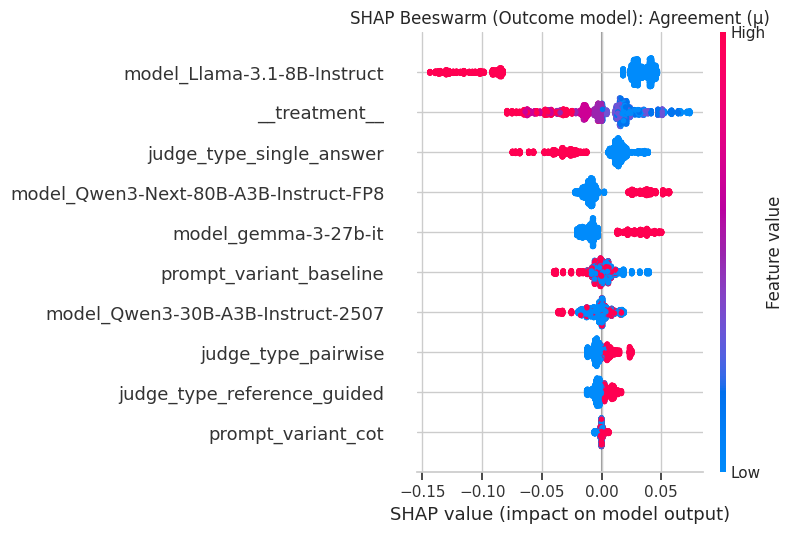

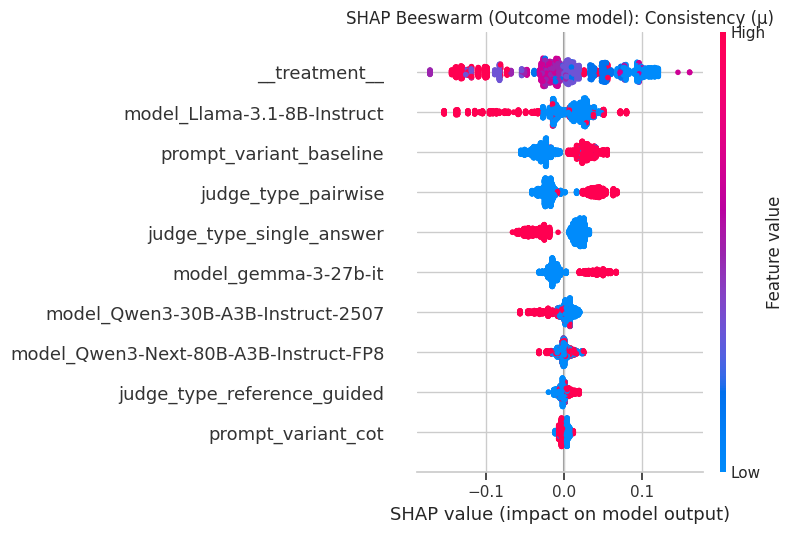

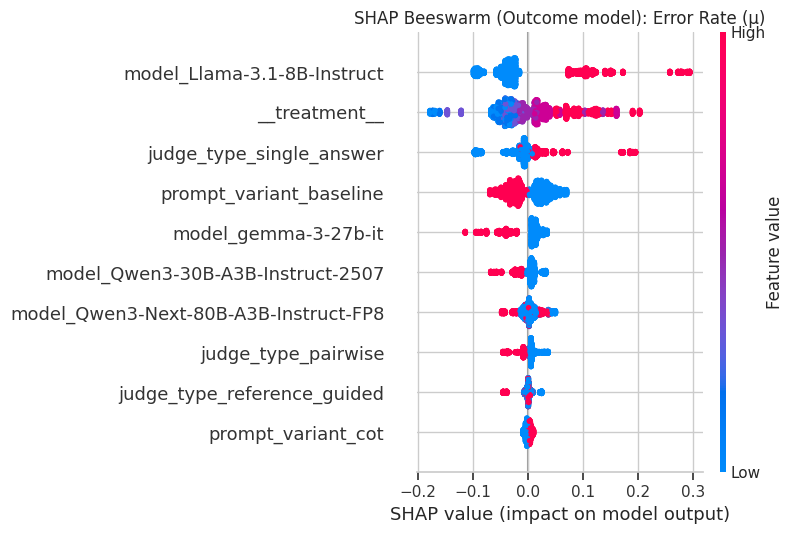

Saved beeswarm plots:
- output/causal_analysis_continuous_treatment/outcome_model_shap_beeswarm_Agreement_mu.png
- output/causal_analysis_continuous_treatment/outcome_model_shap_beeswarm_Consistency_mu.png
- output/causal_analysis_continuous_treatment/outcome_model_shap_beeswarm_Error_Rate_mu.png


In [6]:
display(Markdown("## Extra: SHAP Beeswarm"))

beeswarm_paths = []

for outcome_col in METRIC_COLUMNS:
    nuisance_df, X_outcome, _, outcome_model, _ = fit_global_nuisance_models(combined_df, outcome_col)

    model_feature_df = X_outcome.copy()
    sample_idx = model_feature_df.sample(min(len(model_feature_df), 3000), random_state=2026).index
    sample_model_df = model_feature_df.loc[sample_idx]

    explainer = shap.TreeExplainer(outcome_model)
    explanation = explainer(sample_model_df)

    values = np.asarray(explanation.values)
    if values.ndim == 3:
        values = values[:, :, -1]

    base_values = np.asarray(explanation.base_values)
    if np.ndim(base_values) > 1:
        base_values = base_values[:, -1]

    beeswarm_exp = shap.Explanation(
        values=values,
        base_values=base_values,
        data=sample_model_df.to_numpy(),
        feature_names=list(sample_model_df.columns),
    )

    plt.figure(figsize=(8, 5))
    shap.plots.beeswarm(beeswarm_exp, max_display=12, show=False)
    plt.title(f"SHAP Beeswarm (Outcome model): {outcome_col}")
    plt.tight_layout()

    safe_name = (
        outcome_col
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
        .replace("µ", "mu")
        .replace("/", "_")
    )
    beeswarm_path = FIG_DIR / f"outcome_model_shap_beeswarm_{safe_name}.png"
    plt.savefig(beeswarm_path, dpi=220, bbox_inches="tight")
    plt.show()
    beeswarm_paths.append(beeswarm_path)

print("Saved beeswarm plots:")
for p in beeswarm_paths:
    print("-", p)